# Segmentation Benchmark

Evaluate segmentation models on HyperData validation datasets.

| Step | Description |
|------|-------------|
| §1 | Setup & connect to HyperData |
| §2 | Pull validation dataset |
| §3 | Build models (encoder+head, open-source segmenters) |
| §4 | Run benchmark |
| §5 | Visualize results |

## 1. Setup

In [1]:
%matplotlib inline
import os

# ---- Default HyperData remote configuration ----
# ---- Default HyperData remote configuration ----
os.environ.setdefault("HYPERDATA_ENDPOINT", "http://118.180.19.234:8021")
os.environ.setdefault("MINIO_ENDPOINT", "118.180.19.234")
os.environ.setdefault("MINIO_PORT", "9010")
os.environ.setdefault("MINIO_ACCESS_KEY", "hyperdata_admin")
os.environ.setdefault("MINIO_SECRET_KEY", "change-this-password-in-production")
os.environ.setdefault("S3_ENDPOINT", "118.180.19.234")
os.environ.setdefault("S3_PORT", "9010")
os.environ.setdefault("S3_ACCESS_KEY", "hyperdata_admin")
os.environ.setdefault("S3_SECRET_KEY", "change-this-password-in-production")
os.environ.setdefault("S3_BUCKET", "hyperdata-data")

import numpy as np
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu130


## 2. Pull Validation Dataset

Pull the `fibsem_val_dataset_sample` from HyperData S3.

The dataset contains 12 image-label pairs (1024x1024 grayscale TIFF),
stored as stacked Zarr arrays: `images (N,H,W)` + `masks (N,H,W)` + `dataset_meta`.

In [2]:
import subprocess
from pathlib import Path

from hyperdata import HyperData

DATASET_NAME = "fibsem_val_dataset_sample"
LOCAL_DIR = f"/tmp/{DATASET_NAME}"

# Pull from HyperData hub (downloads Zarr chunks from S3)
local_path = Path(LOCAL_DIR) / DATASET_NAME
if not local_path.exists():
    print(f"Pulling {DATASET_NAME} from HyperData hub...")
    subprocess.run(
        ["hd", "pull", DATASET_NAME, "-o", LOCAL_DIR],
        check=True,
    )
else:
    print(f"Dataset already exists at {local_path}")

# Open as HyperData and verify
ds = HyperData(str(local_path))
print(f"Keys: {ds.keys()}")
print(f"Images: {ds['images'].shape}")
print(f"Masks:  {ds['masks'].shape}")

Dataset already exists at /tmp/fibsem_val_dataset_sample/fibsem_val_dataset_sample
  2026-05-22T09:27:30.773227Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

Keys: ['dataset_meta', 'images', 'masks']
Images: (12, 1024, 1024)
Masks:  (12, 1024, 1024)


In [3]:
# Load into benchmark dataset loader
from lumen.benchmark.dataset import ValDatasetLoader

val_ds = ValDatasetLoader(
    path=str(local_path),
    channels=1,
    image_size=512,  # resize for faster inference
)

print(f"Samples: {len(val_ds)}")
print(f"Names: {val_ds.names}")
print(f"Num classes: {val_ds.num_classes}")
print(f"Metadata: {val_ds.meta}")

  2026-05-22T09:27:30.844403Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



Samples: 12
Names: ['step0_create_marker_fib_60um', 'step0_create_marker_sem_60um', 'step1_protection_layer_fib_60um', 'step1_protection_layer_sem_60um', 'step2_trench_milling_fib_60um', 'step2_trench_milling_sem_60um', 'step3_trench_polish_fib_60um', 'step3_trench_polish_sem_60um', 'step4_ucut_fib_60um', 'step4_ucut_pre_fib_60um', 'step4_ucut_pre_sem_60um', 'step4_ucut_sem_60um']
Num classes: 10
Metadata: {'num_samples': 12, 'image_shape': [1024, 1024], 'image_dtype': 'uint8', 'mask_dtype': 'uint8', 'sample_names': ['step0_create_marker_fib_60um', 'step0_create_marker_sem_60um', 'step1_protection_layer_fib_60um', 'step1_protection_layer_sem_60um', 'step2_trench_milling_fib_60um', 'step2_trench_milling_sem_60um', 'step3_trench_polish_fib_60um', 'step3_trench_polish_sem_60um', 'step4_ucut_fib_60um', 'step4_ucut_pre_fib_60um', 'step4_ucut_pre_sem_60um', 'step4_ucut_sem_60um'], 'name': 'fibsem_val_dataset_sample', 'version': '1.0', 'domain': 'fibsem', 'description': 'FIB-SEM validation da

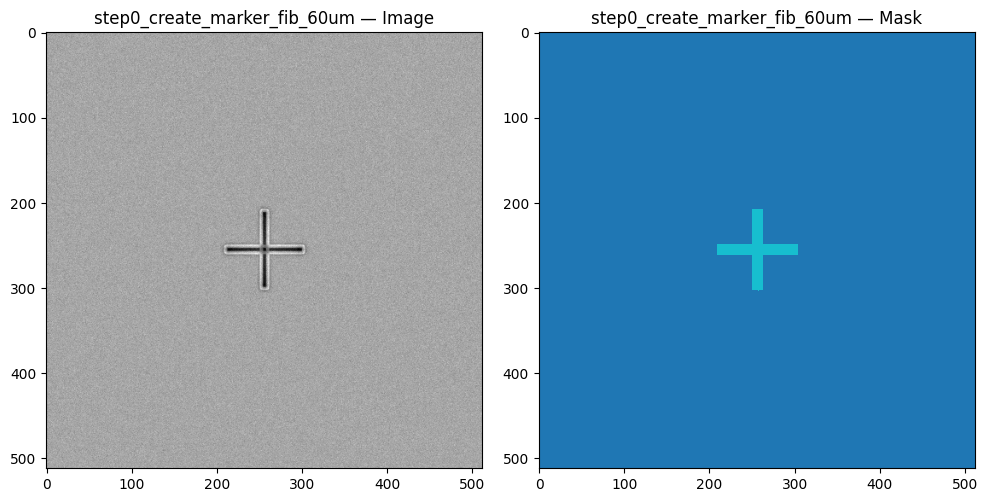

In [4]:
# Preview a sample
import matplotlib.pyplot as plt

sample = val_ds[0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(sample.image[0].numpy(), cmap="gray")
ax1.set_title(f"{sample.name} — Image")
ax2.imshow(sample.mask.numpy(), cmap="tab10", interpolation="nearest")
ax2.set_title(f"{sample.name} — Mask")
plt.tight_layout()
plt.show()

## 3. Build Models

We benchmark multiple model types:

1. **Encoder + SegmentationHead** — local trained models or pretrained encoders
2. **Open-source segmenters** — SAM3, DINOv3, TIPSv2 via Lumen's registry

Adjust the cells below to add/remove models as needed.

In [5]:
from lumen.benchmark.runner import BenchmarkRunner, ModelSpec
from lumen.models.encoder_base import EncoderBase
from lumen.models.heads import SegmentationHead

NUM_CLASSES = val_ds.num_classes
IMAGE_SIZE = 512

# --- Model 1: Tiny baseline encoder (random init) ---
class TinyEncoder(EncoderBase):
    """Minimal encoder for baseline comparison."""
    def __init__(self, patch_size=16, in_channels=1, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.supports_masked_tokens = False
        self.proj = torch.nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size,
        )
        self.blocks = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=4, dim_feedforward=256,
                batch_first=True, norm_first=True,
            ),
            num_layers=2,
        )
        self.norm = torch.nn.LayerNorm(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.blocks(x)
        return self.norm(x)

tiny_enc = TinyEncoder(patch_size=16, in_channels=1, embed_dim=64)
tiny_head = SegmentationHead(
    embed_dim=64, num_classes=NUM_CLASSES, patch_size=16,
)

print(f"Tiny encoder params: {sum(p.numel() for p in tiny_enc.parameters()):,}")
print(f"Tiny head params: {sum(p.numel() for p in tiny_head.parameters()):,}")

Tiny encoder params: 116,544
Tiny head params: 153,994


/tmp/ipykernel_1832731/1897525771.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = torch.nn.TransformerEncoder(


In [6]:
# --- Model 2: DINOv3 encoder with official linear head ---
from lumen.models import DINOv3Encoder, DINOv3LinearSegmentationHead
dinov3_enc = DINOv3Encoder(
    model_dir="/root/.cache/modelscope/hub/models/facebook/dinov2-small",
    device=DEVICE,
    local_files_only=True,
)
dinov3_head = DINOv3LinearSegmentationHead(
    embed_dim=dinov3_enc.embed_dim,
    num_classes=NUM_CLASSES,
    patch_size=dinov3_enc.patch_size,
    num_feature_levels=1,
)
print(f"DINOv3 embed_dim={dinov3_enc.embed_dim}, patch_size={dinov3_enc.patch_size}")


/data/codes/lumen/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 4611.83it/s]

DINOv3 embed_dim=384, patch_size=14


In [7]:
# --- Quick head training for DINOv3 (freeze encoder) ---
from torch.utils.data import DataLoader, Dataset

class _DictDS(Dataset):
    def __init__(self, loader):
        self.loader = loader
    def __len__(self):
        return len(self.loader)
    def __getitem__(self, idx):
        s = self.loader[idx]
        return {"image": s.image, "mask": s.mask}

dinov3_enc.eval()
for p in dinov3_enc.parameters():
    p.requires_grad = False

train_loader = DataLoader(_DictDS(val_ds), batch_size=2, shuffle=True)
optimizer = torch.optim.AdamW(dinov3_head.parameters(), lr=1e-3)
dinov3_head.to(DEVICE)
criterion = torch.nn.CrossEntropyLoss()

EPOCHS = 3
dinov3_head.train()
for epoch in range(EPOCHS):
    losses = []
    for batch in train_loader:
        img = batch["image"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)
        with torch.no_grad():
            tokens = dinov3_enc(img)
        logits = dinov3_head(tokens, image_size=(img.shape[2], img.shape[3]))
        loss = criterion(logits, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    print(f"Epoch {epoch+1}/{EPOCHS} loss: {sum(losses)/len(losses):.4f}")
dinov3_head.eval()
print("DINOv3 head trained.")


Epoch 1/3 loss: 2.2918
Epoch 2/3 loss: 2.2277


Epoch 3/3 loss: 2.1677
DINOv3 head trained.


In [8]:
# --- Model 3: SAM3 segmenter from ModelScope ---
from lumen.models import build_segmenter
sam3_seg = build_segmenter(
    "sam3",
    model_dir="/root/.cache/modelscope/hub/models/facebook/sam3",
    device=DEVICE,
    local_files_only=True,
)
print(f"SAM3 image_size={sam3_seg.image_size}")


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Loading weights:  35%|███▌      | 515/1468 [00:00<00:00, 5145.04it/s]

Loading weights:  70%|███████   | 1030/1468 [00:00<00:00, 4528.22it/s]

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 4609.34it/s]

SAM3 image_size=(1008, 1008)


## 4. Run Benchmark

In [9]:
runner = BenchmarkRunner(val_ds, num_classes=NUM_CLASSES)

# Add the tiny baseline
runner.add_model(ModelSpec(
    name="tiny-baseline (random)",
    encoder=tiny_enc,
    head=tiny_head,
    device=DEVICE,
))

# Add DINOv3:
runner.add_model(ModelSpec(
    name="dinov3-small",
    encoder=dinov3_enc,
    head=dinov3_head,
    device=DEVICE,
))

results = runner.run()

# SAM3 with per-sample text prompts (outside runner for finer control)
import time
import numpy as np
from lumen.benchmark.metrics import compute_metrics, summarize_results
from lumen.benchmark.runner import BenchmarkResult

sample_prompts = {
    "step0_create_marker_fib_60um": "marker",
    "step0_create_marker_sem_60um": "marker",
    "step1_protection_layer_fib_60um": "protection layer",
    "step1_protection_layer_sem_60um": "protection layer",
    "step2_trench_milling_fib_60um": "milled trench",
    "step2_trench_milling_sem_60um": "milled trench",
    "step3_trench_polish_fib_60um": "polished trench",
    "step3_trench_polish_sem_60um": "polished trench",
    "step4_ucut_fib_60um": "ultramicrotomy section",
    "step4_ucut_pre_fib_60um": "ultramicrotomy section",
    "step4_ucut_pre_sem_60um": "ultramicrotomy section",
    "step4_ucut_sem_60um": "ultramicrotomy section",
}

t0 = time.time()
sam3_sample_results = []
for i in range(len(val_ds)):
    sample = val_ds[i]
    h, w = sample.mask.shape
    img_np = sample.image.permute(1, 2, 0).numpy()
    if img_np.shape[-1] == 1:
        img_np = np.repeat(img_np, 3, axis=-1)
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    prompt = sample_prompts.get(sample.name, "structure")
    detections = sam3_seg.predict(img_np, text=[prompt])
    pred = torch.zeros(h, w, dtype=torch.long)
    if hasattr(detections, "mask") and detections.mask is not None:
        for idx, m in enumerate(detections.mask):
            class_id = (
                int(detections.class_id[idx])
                if detections.class_id is not None
                else idx + 1
            )
            pred[torch.from_numpy(m)] = class_id
    sr = compute_metrics(pred, sample.mask, NUM_CLASSES, name=sample.name, index=sample.index)
    sam3_sample_results.append(sr)

sam3_summary = summarize_results(sam3_sample_results)
sam3_elapsed = time.time() - t0
sam3_result = BenchmarkResult(
    model_name="sam3 (per-sample prompts)",
    dataset_path=val_ds.path,
    summary=sam3_summary,
    per_sample=sam3_sample_results,
    elapsed_seconds=sam3_elapsed,
)
results.append(sam3_result)

# SAM3 binary foreground evaluation (more fair for zero-shot segmenter)
sam3_binary_results = []
for i in range(len(val_ds)):
    sample = val_ds[i]
    h, w = sample.mask.shape
    img_np = sample.image.permute(1, 2, 0).numpy()
    if img_np.shape[-1] == 1:
        img_np = np.repeat(img_np, 3, axis=-1)
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    prompt = sample_prompts.get(sample.name, "structure")
    detections = sam3_seg.predict(img_np, text=[prompt])
    pred_fg = torch.zeros(h, w, dtype=torch.bool)
    if hasattr(detections, "mask") and detections.mask is not None:
        for m in detections.mask:
            pred_fg |= torch.from_numpy(m)
    pred_binary = pred_fg.long()
    target_binary = (sample.mask != 0).long()
    sr_bin = compute_metrics(pred_binary, target_binary, 2, name=sample.name, index=sample.index)
    sam3_binary_results.append(sr_bin)

sam3_bin_summary = summarize_results(sam3_binary_results)
sam3_bin_result = BenchmarkResult(
    model_name="sam3 (binary foreground)",
    dataset_path=val_ds.path,
    summary=sam3_bin_summary,
    per_sample=sam3_binary_results,
    elapsed_seconds=0.0,
)
results.append(sam3_bin_result)

for r in results:
    print()
    print(f"{r.model_name}:")
    print(f"  mIoU:     {r.summary['mean_iou']:.4f}")
    print(f"  Dice:     {r.summary['mean_dice']:.4f}")
    print(f"  Pixel Acc: {r.summary['mean_pixel_acc']:.4f}")
    print(f"  Time:     {r.elapsed_seconds:.1f}s")



tiny-baseline (random):
  mIoU:     0.0035
  Dice:     0.0067
  Pixel Acc: 0.0143
  Time:     0.4s

dinov3-small:
  mIoU:     0.1231
  Dice:     0.1565
  Pixel Acc: 0.7829
  Time:     4.3s

sam3 (per-sample prompts):
  mIoU:     0.2844
  Dice:     0.2880
  Pixel Acc: 0.9713
  Time:     10.6s

sam3 (binary foreground):
  mIoU:     0.4856
  Dice:     0.4927
  Pixel Acc: 0.9713
  Time:     0.0s


## 5. Visualize Results

Models in this benchmark:
  1. tiny-baseline (random)
  2. dinov3-small
  3. sam3 (per-sample prompts)
  4. sam3 (binary foreground)


,Model,mIoU,Dice,Pixel Acc,Samples,Time (s)
0,tiny-baseline (random),0.003454,0.006679,0.014309,12,0.399671
1,dinov3-small,0.123072,0.156472,0.782858,12,4.265542
2,sam3 (per-sample prompts),0.284422,0.287976,0.971278,12,10.634775
3,sam3 (binary foreground),0.485639,0.492678,0.971278,12,0.000000


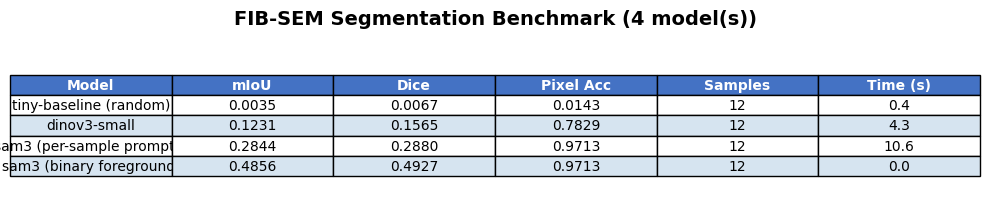

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from lumen.benchmark.visualize import plot_summary_table, plot_predictions

# Summary table comparing all models
table_data = []
for r in results:
    entry = dict(r.summary)
    entry["model_name"] = r.model_name
    entry["elapsed_seconds"] = r.elapsed_seconds
    table_data.append(entry)

model_names = [r["model_name"] for r in table_data]
print("Models in this benchmark:")
for i, name in enumerate(model_names, start=1):
    print(f"  {i}. {name}")

# Show an explicit tabular preview so the model column is always visible.
summary_df = pd.DataFrame(table_data)[
    ["model_name", "mean_iou", "mean_dice", "mean_pixel_acc", "num_samples", "elapsed_seconds"]
]
summary_df = summary_df.rename(
    columns={
        "model_name": "Model",
        "mean_iou": "mIoU",
        "mean_dice": "Dice",
        "mean_pixel_acc": "Pixel Acc",
        "num_samples": "Samples",
        "elapsed_seconds": "Time (s)",
    }
)
display(summary_df)

fig = plot_summary_table(
    table_data,
    title=f"FIB-SEM Segmentation Benchmark ({len(model_names)} model(s))",
)
plt.show()

Visualizing: tiny-baseline (random)


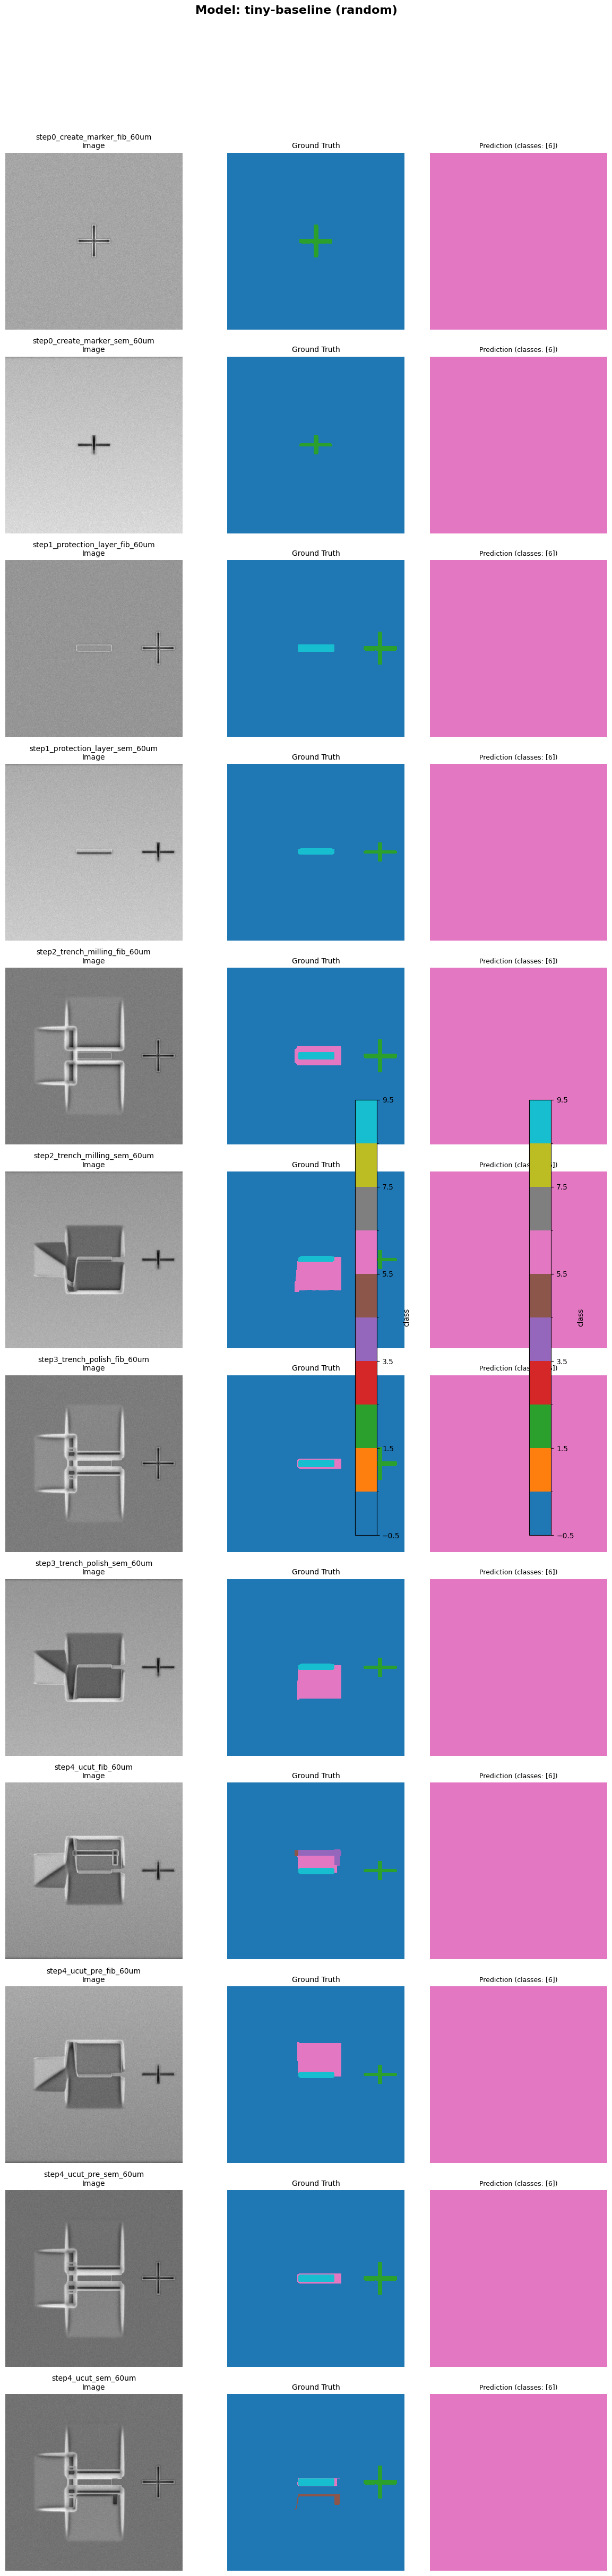

Visualizing: dinov3-small


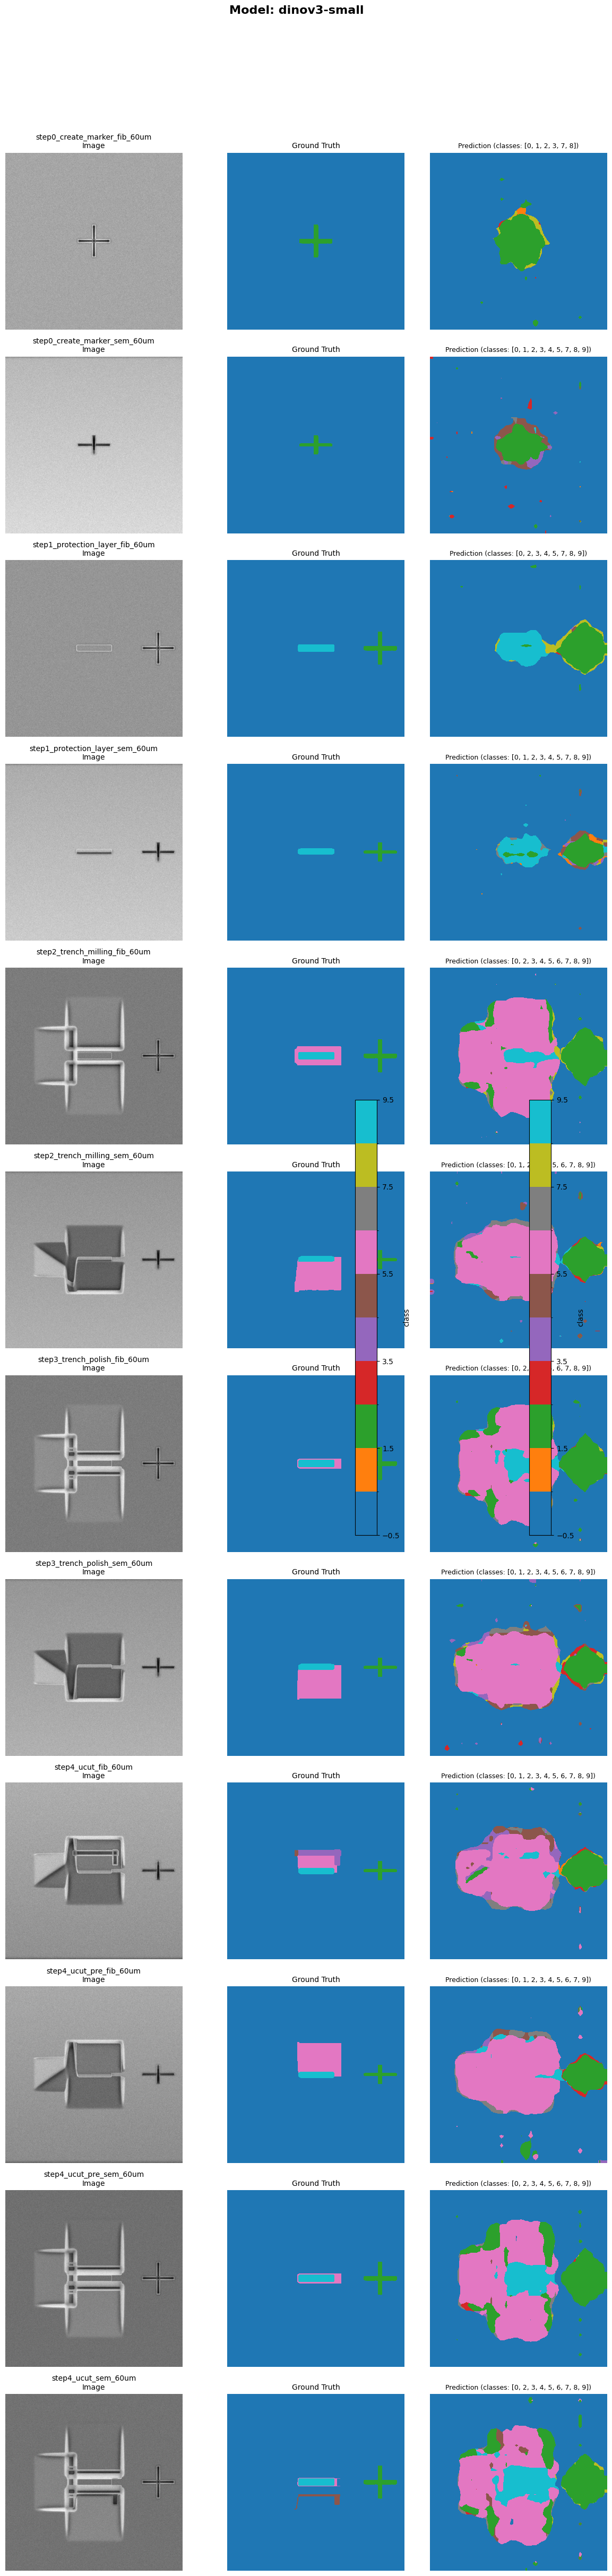

In [11]:
# Per-sample predictions for ALL models (all samples)
import matplotlib.pyplot as plt

n_show = len(val_ds)
images = [val_ds[i].image for i in range(n_show)]
masks = [val_ds[i].mask for i in range(n_show)]
names = [val_ds[i].name for i in range(n_show)]

for spec in runner._models:
    print(f"Visualizing: {spec.name}")
    preds = []
    for i in range(n_show):
        sample = val_ds[i]
        pred = runner._predict(spec, sample)
        preds.append(pred)
    fig = plot_predictions(
        images, masks, preds, names,
        num_classes=NUM_CLASSES,
        model_name=spec.name,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    plt.close(fig)


In [12]:
# Per-sample score breakdown
import pandas as pd

for r in results:
    print(f"\n=== {r.model_name} ===")
    df = pd.DataFrame(r.summary["per_sample"])
    print(df.to_string(index=False))
    print(f"\nMean — mIoU: {r.summary['mean_iou']:.4f}, "
          f"Dice: {r.summary['mean_dice']:.4f}, "
          f"PixAcc: {r.summary['mean_pixel_acc']:.4f}")


=== tiny-baseline (random) ===
                           name      iou     dice  pixel_acc
   step0_create_marker_fib_60um 0.000000 0.000000   0.000000
   step0_create_marker_sem_60um 0.000000 0.000000   0.000000
step1_protection_layer_fib_60um 0.000000 0.000000   0.000000
step1_protection_layer_sem_60um 0.000000 0.000000   0.000000
  step2_trench_milling_fib_60um 0.004699 0.009224   0.018795
  step2_trench_milling_sem_60um 0.010639 0.020410   0.042557
   step3_trench_polish_fib_60um 0.001352 0.002690   0.005409
   step3_trench_polish_sem_60um 0.010226 0.019649   0.040905
            step4_ucut_fib_60um 0.002553 0.005028   0.015316
        step4_ucut_pre_fib_60um 0.010232 0.019659   0.040928
        step4_ucut_pre_sem_60um 0.001350 0.002686   0.005402
            step4_ucut_sem_60um 0.000399 0.000797   0.002396

Mean — mIoU: 0.0035, Dice: 0.0067, PixAcc: 0.0143

=== dinov3-small ===
                           name      iou     dice  pixel_acc
   step0_create_marker_fib_60um 0.178089 